In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [5]:
from google.colab import files

uploaded = files.upload()

Saving Fake.csv to Fake.csv


In [6]:
from google.colab import files

uploaded = files.upload()

Saving True.csv to True.csv


In [17]:
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

print("Fake News Dataset Shape:", fake.shape)
print("True News Dataset Shape:", true.shape)


Fake News Dataset Shape: (23481, 4)
True News Dataset Shape: (21417, 4)


In [18]:
fake["label"] = 0
true["label"] = 1

In [19]:
df = pd.concat([fake, true], axis=0, ignore_index=True)

print("Combined Dataset Shape:", df.shape)

Combined Dataset Shape: (44898, 5)


In [20]:
df = df[["title", "text", "label"]]

df = df.dropna()

print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
title    0
text     0
label    0
dtype: int64


In [21]:
df["content"] = df["title"] + " " + df["text"]

df = df[["content", "label"]]

print("\nDataset:")
print(df.head())


Dataset:
                                             content  label
0   Donald Trump Sends Out Embarrassing New Year’...      0
1   Drunk Bragging Trump Staffer Started Russian ...      0
2   Sheriff David Clarke Becomes An Internet Joke...      0
3   Trump Is So Obsessed He Even Has Obama’s Name...      0
4   Pope Francis Just Called Out Donald Trump Dur...      0


In [22]:
print("\nNews Count:")
print(df["label"].value_counts())



News Count:
label
0    23481
1    21417
Name: count, dtype: int64


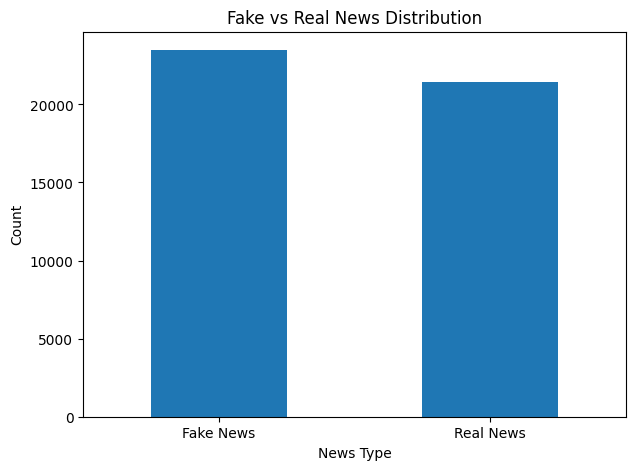

In [23]:
plt.figure(figsize=(7, 5))

df["label"].value_counts().sort_index().plot(
    kind="bar"
)

plt.xticks(
    [0, 1],
    ["Fake News", "Real News"],
    rotation=0
)

plt.xlabel("News Type")
plt.ylabel("Count")

plt.title("Fake vs Real News Distribution")

plt.show()


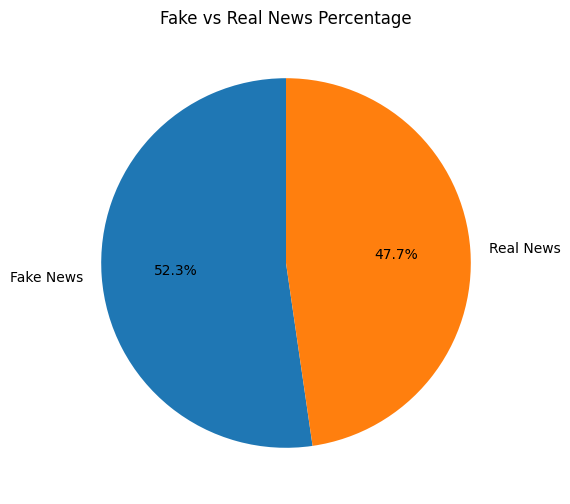

In [24]:
plt.figure(figsize=(6, 6))

df["label"].value_counts().sort_index().plot(
    kind="pie",
    labels=["Fake News", "Real News"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Fake vs Real News Percentage")

plt.ylabel("")

plt.show()

In [25]:

X = df["content"]
y = df["label"]

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)



Training Data: (35918,)
Testing Data: (8980,)


In [27]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_df=0.7,
    max_features=50000
)

X_train_vectorized = vectorizer.fit_transform(X_train)

X_test_vectorized = vectorizer.transform(X_test)

print("\nTF-IDF Vectorization Completed!")



TF-IDF Vectorization Completed!


In [28]:
model = MultinomialNB()

model.fit(
    X_train_vectorized,
    y_train
)

print("Naive Bayes Model Training Completed!")

Naive Bayes Model Training Completed!


In [29]:
y_pred = model.predict(X_test_vectorized)

print("\nFirst 10 Predictions:")
print(y_pred[:10])


First 10 Predictions:
[1 1 0 1 1 0 1 0 1 1]


In [30]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nModel Accuracy:")
print(accuracy * 100, "%")



Model Accuracy:
93.69710467706014 %


In [31]:
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Fake News", "Real News"]
    )
)



Classification Report:
              precision    recall  f1-score   support

   Fake News       0.94      0.94      0.94      4696
   Real News       0.93      0.93      0.93      4284

    accuracy                           0.94      8980
   macro avg       0.94      0.94      0.94      8980
weighted avg       0.94      0.94      0.94      8980



In [32]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)



Confusion Matrix:
[[4414  282]
 [ 284 4000]]


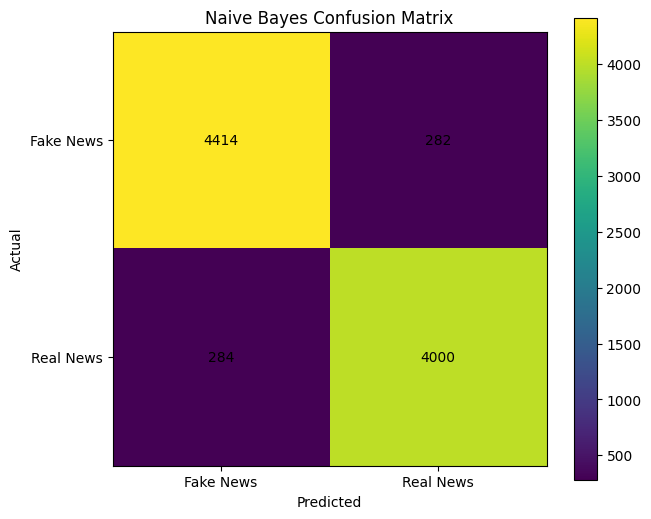

In [33]:
plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.colorbar()

plt.xticks(
    [0, 1],
    ["Fake News", "Real News"]
)

plt.yticks(
    [0, 1],
    ["Fake News", "Real News"]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Naive Bayes Confusion Matrix")


for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )


plt.show()

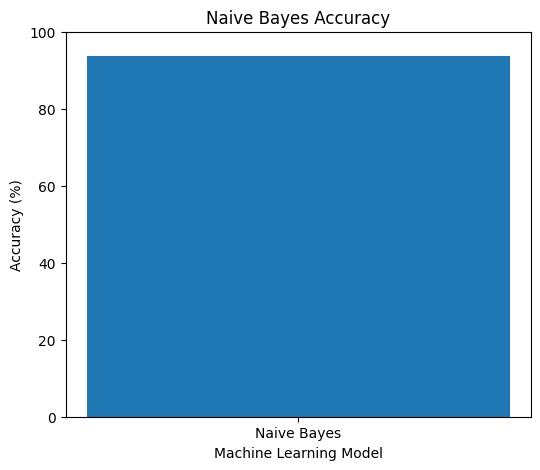

In [34]:
plt.figure(figsize=(6, 5))

plt.bar(
    ["Naive Bayes"],
    [accuracy * 100]
)

plt.xlabel("Machine Learning Model")

plt.ylabel("Accuracy (%)")

plt.title("Naive Bayes Accuracy")

plt.ylim(0, 100)

plt.show()

In [36]:
def predict_news(news):

    news_vector = vectorizer.transform([news])

    prediction = model.predict(news_vector)

    if prediction[0] == 0:
        return "FAKE NEWS"

    else:
        return "REAL NEWS"



In [37]:
news = input("\nEnter a news article: ")

result = predict_news(news)

print("\nPrediction:", result)


Enter a news article: Scientists have developed a new technology that could improve renewable energy production. Researchers said the technology may help increase the efficiency of solar and wind power systems. Further testing will be conducted before the technology is widely adopted.

Prediction: REAL NEWS


In [38]:
news = input("\nEnter a news article: ")

result = predict_news(news)

print("\nPrediction:", result)


Enter a news article: Scientists have announced that drinking a special homemade mixture can make people live for more than 200 years. The secret formula is said to work immediately and requires no medical treatment or scientific testing.

Prediction: FAKE NEWS
